## Importing Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import( mean_absolute_error,mean_squared_error,r2_score)

## TASK:1.Data Loading & Exploration

####  1.1 Load the CSV file using Pandas

In [4]:
df=pd.read_csv("Housing.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


#### 1.2 Display the First 10 Rows

In [5]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


#### 1.3 Check Dataset Shape

In [6]:
print("Rows and Columns:",df.shape)

Rows and Columns: (545, 13)


#### 1.4 Display Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


#### 1.5 Display Column Names

In [10]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

#### 1.6 Identify Target and Feature Variables

In [11]:
target="price"
features=df.drop("price",axis=1).columns
print("Target Variable:",target)
print("Features Variables:")
print(features)

Target Variable: price
Features Variables:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


#### 1.7 check Missing Values

In [12]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

#### 1.8 Display Statistical Summary

In [13]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## TASK:2.Data Cleaning & Preprocessing

#### 2.1 Check Duplicate Records

In [14]:
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 0


#### 2.2 Remove Duplicate Records

In [15]:
df.drop_duplicates(inplace=True) #no duplicates in the given dataset

#### 2.3 Handle Missing Values

In [16]:
df.fillna(df.median(numeric_only=True),inplace=True) #no missing values in the given dataset

#### 2.4 Convert Categorical Columns into Numerical Values

In [17]:
df=pd.get_dummies(df,drop_first=True)

#### 2.5 Display Cleaned Dataset

In [18]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


#### 2.6 Verify Dataset Information After Cleaning

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

## TASK:3.Model Building

#### 3.1 Separate Features and Target

In [20]:
x=df.drop("price",axis=1)
x

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,7420,4,1,2,2,True,True,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,True,False,True,False,False,False,False,True
541,2400,3,1,1,0,False,False,False,False,False,False,True,False
542,3620,2,1,1,0,True,False,False,False,False,False,False,True
543,2910,3,1,1,0,False,False,False,False,False,False,False,False


In [22]:
y=df["price"]
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

#### 3.2 Split Dataset into Training and Testing Sets

In [57]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.20,
    random_state=42)

In [56]:
x_train

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,6000,3,2,4,1,True,False,False,False,True,False,False,False
93,7200,3,2,1,3,True,False,True,False,True,False,True,False
335,3816,2,1,1,2,True,False,True,False,True,False,False,False
412,2610,3,1,2,0,True,False,True,False,False,True,False,True
471,3750,3,1,2,0,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,0,True,False,False,False,True,False,False,True
106,5450,4,2,1,0,True,False,True,False,True,True,True,False
270,4500,3,2,3,1,True,False,False,True,False,False,False,False
435,4040,2,1,1,0,True,False,False,False,False,False,False,True


In [52]:
x_test

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,5900,4,2,2,1,False,False,True,False,False,False,False,True
77,6500,3,2,3,0,True,False,False,False,True,True,False,False
360,4040,2,1,1,0,True,False,False,False,False,False,True,False
90,5000,3,1,2,0,True,False,False,False,True,False,True,False
493,3960,3,1,1,0,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,6000,4,1,2,2,True,False,True,False,False,False,True,False
357,6930,4,1,2,1,False,False,False,False,False,False,False,False
39,6000,4,2,4,1,True,False,False,False,True,False,True,False
54,6000,3,2,2,1,True,True,False,False,True,False,True,False


In [53]:
y_train

46     7525000
93     6300000
335    3920000
412    3430000
471    3010000
        ...   
71     6755000
106    6160000
270    4340000
435    3290000
102    6195000
Name: price, Length: 436, dtype: int64

In [54]:
y_test

316    4060000
77     6650000
360    3710000
90     6440000
493    2800000
        ...   
15     9100000
357    3773000
39     7910000
54     7350000
155    5530000
Name: price, Length: 109, dtype: int64

### Linear Regression Model

#### 3.3 Train the Linear Regression Model

In [24]:
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

#### 3.4 Predict House Prices

In [26]:
y_pred_lr=lr.predict(x_test)
y_pred_lr

array([5164653.90033967, 7224722.29802166, 3109863.24240338,
       4612075.32722559, 3294646.25725955, 3532275.09556558,
       5611774.56836476, 6368145.98732718, 2722856.95689985,
       2629405.61585782, 9617039.5031558 , 2798087.30447888,
       3171096.76847063, 3394639.09125528, 3681088.65424275,
       5263187.74621485, 3035963.47612384, 4786122.8004005 ,
       4349551.9200572 , 3572362.09930451, 5774875.21395649,
       5886993.57919883, 2730836.19518458, 4727316.47323635,
       5244847.52716801, 7555324.21605603, 3220790.84680268,
       5191898.79934207, 8143726.91009786, 3398814.09825035,
       6490693.05027925, 3315105.9074781 , 6708457.36761326,
       4201738.21071676, 3557571.06735186, 5836974.50478626,
       4808660.67448475, 4362878.73613261, 3191242.95701508,
       4596554.93225238, 4566042.86048411, 3517779.52374148,
       7205844.79365835, 3983597.27861103, 3749338.70271056,
       4274731.09125895, 6757442.10783741, 4037320.43665851,
       3769334.90397126,

#### 3.5 Evaluate Linear Regression Model

In [28]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression Results")
print("--------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

Linear Regression Results
--------------------------
MAE : 970043.403920164
RMSE: 1324506.9600914388
R² Score: 0.6529242642153184


### Random Forest Regression Model

#### 3.6 Train the Random Forest Regressor

In [31]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

#### 3.7 Predict House Prices

In [33]:
y_pred_rf = rf.predict(x_test)
y_pred_rf

array([5377680.        , 7287070.        , 3747528.75      ,
       4502120.        , 3748885.        , 3432660.        ,
       5070240.        , 5050080.        , 2572220.        ,
       2822893.5       , 9973209.4       , 3347465.        ,
       3023883.33333333, 3469340.        , 3561320.        ,
       3912510.        , 3305785.        , 4852645.        ,
       3669330.        , 4101405.        , 5433260.        ,
       5932920.        , 3067236.66666667, 3658130.        ,
       4722200.        , 6532505.        , 3081540.        ,
       4601170.        , 6330240.        , 3258150.        ,
       5765550.        , 3192490.        , 6748420.        ,
       4366460.        , 2947875.        , 6350050.        ,
       4867170.        , 3685920.        , 3106670.        ,
       4171650.        , 4146100.        , 2857015.        ,
       7453390.        , 4196290.        , 4011070.        ,
       4339300.        , 7316050.        , 4098360.        ,
       3011960.        ,

#### 3.8 Evaluate Random Forest Model

In [34]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
---------------------
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


#### 3.9 Compare Both Models

In [35]:
comp = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R² Score": [r2_lr, r2_rf]
})
comp

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


## TASK 4-Data Visualization

In [68]:
import os
os.makedirs("charts", exist_ok=True)

#### 4.1 Histogram of House Prices

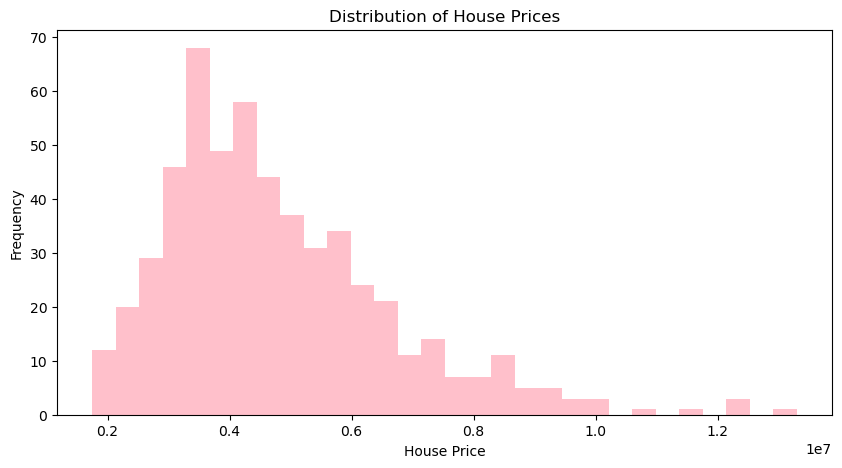

In [74]:
plt.figure(figsize=(10,5))
plt.hist(df["price"], bins=30,color="pink")
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.savefig("charts/house_price_distribution.png")
plt.show()

#### 4.2 Correlation Heatmap

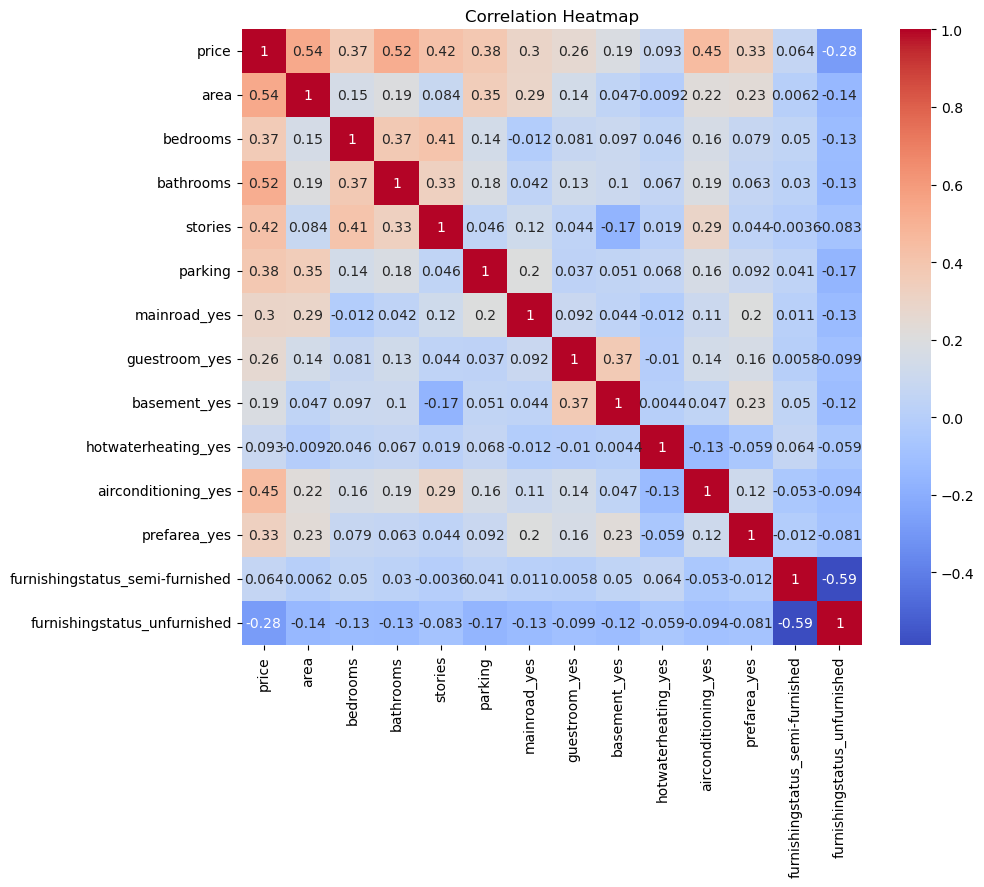

In [75]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.savefig("charts/correlation_heatmap.png")
plt.show()

#### 4.3 Actual vs Predicted Prices

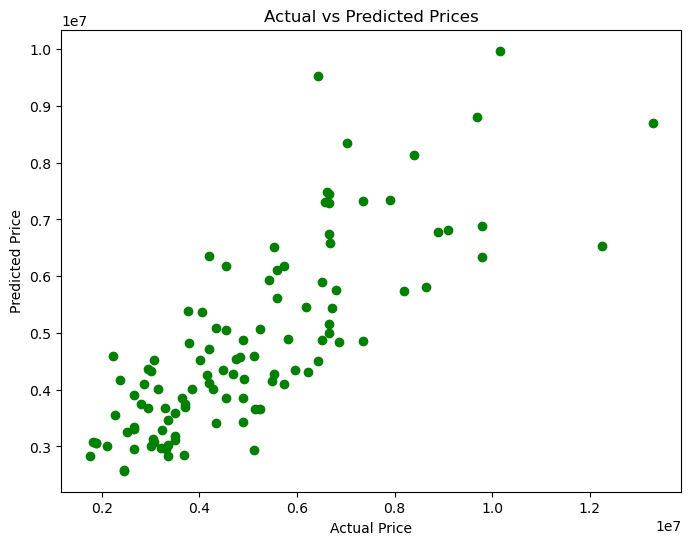

In [76]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf,color="Green")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.savefig("charts/actual_vs_predicted.png")
plt.show()

#### 4.4 Feature Importance

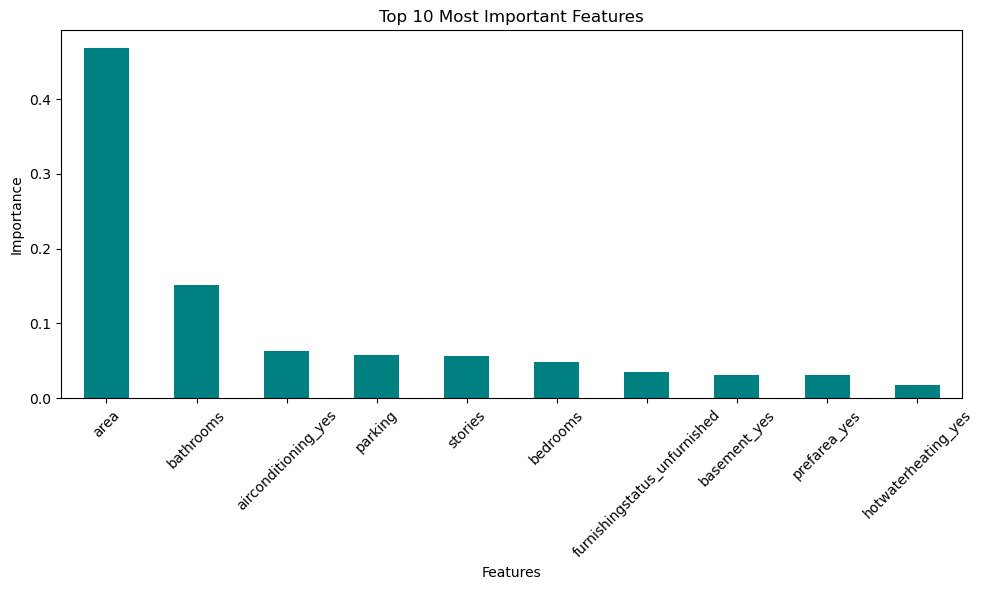

In [72]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

feature_importance.head(10).plot(
    kind="bar",
    color="teal"
)
plt.title("Top 10 Most Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/feature_importance.png", dpi=300)
plt.show()

#### 4.5 Actual vs Predicted with Reference Line

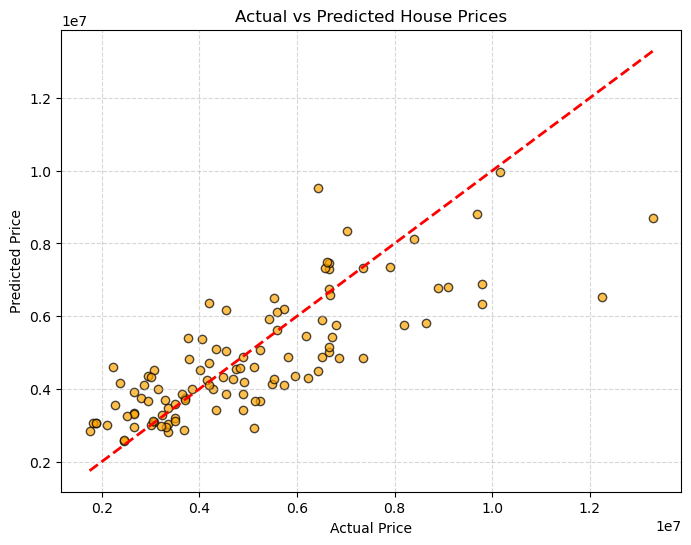

In [77]:
plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    y_pred_rf,
    color="orange",
    alpha=0.7,
    edgecolors="black"
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2,
    linestyle="--"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("charts/actual_vs_predicted with reference line.png", dpi=300)
plt.show()